# 1. Структура базы данных в 1НФ:
### Все значения полей не являются составными, значит условие 1НФ выполнено.
### Листинг кода, для создания диаграммы БД в 1НФ в dbml (язык разметки dbdiagram.io):
```dbml
Table transactions {
  // Идентификатор транзакции, значения в таблице представлены целыми числами,
  // для таблицы с транзакциями может выступать первичным ключем
  transaction_id int [pk]
  // Идентификатор продукта, значения в таблице представлены целыми числами
  product_id int
  // Идентификатор клиента, значения в таблице представлены целыми числами,
  // выступает внешним ключем для связи с таблицей покупателей
  customer_id int
  // Дата проведения операции, разделитель разрядов '/', тип поля data
  transaction_date date
  // Булевое значение, подтверждающее факт онлайн транзацкии (покупки),
  // встречаются пустые записи
  online_order bool
  // Булевое значение, об успешности транзакции (покупки)
  order_status bool
  // Название бренда товара, символьное поле,
  // встречаются пустые записи
  brand varchar
  // Продуктовая линейка (вид продукта), символьное поле,
  // встречаются пустые записи
  product_line varchar
  // Класс продукта, имеет три значения, поэтому символьное поле,
  // встречаются пустые записи
  product_class varchar
  // Размер продукта, имеет три значения, поэтому символьное поле,
  // встречаются пустые записи
  product_size varchar
  // Списочная цена, похоже цена покупки в конкретной транзакции, число с 
  // с плавающей точкой, значит поле float
  list_price float
  // Стандартная стоимость единицы товара, число с плавающей точкой,
  // значит float. Встречаются пустые записи
  standard_cost float
}

Table customers {
  // Идентификатор клиента, значения в таблице представлены целыми числами,
  // для таблицы с покупателями выступает первичным ключем, участвует в
  // связи с таблицей транзакций
  customer_id int [pk]
  // Имя покупателя, символьное поле
  first_name varchar
  // Фамилия покупателя, символьное поле, встречаются пустые значения
  last_name varchar
  // Пол покупателя, просится тип bool, но в таблице встречается 5 различных
  // значений, поэтому пока varchar (до приведения в порядок данных)
  gender varchar
  // Дата рождения пользователя, тип поля дата, есть пустые значения
  DOB date
  // Название рабочей профессии, символьное поле, есть пустые значения
  job_title varchar
  // Название группы отрасли, символьное поле, есть значения 'n/a'
  job_industry_category varchar
  // Сегментирование покупателей на группы, три значения, поэтому символьное поле
  wealth_segment varchar
  // Статус по потере клиента, булевое значение
  deceased_indicator bool
  // Наличие автомобиля, булевое значение
  owns_car bool
  // Адрес покупателя, символьное поле
  address varchar
  // Почтовый код, представлен целыми числами
  postcode int
  // Штат, символьное поле
  state varchar
  // Страна, символьное поле
  country varchar
  // Сегментация по благосостоянию/рейтинг стоимости недвижимости, числовое поле
  property_valuation int
}

// Связь двух таблиц один (customers) ко многим (transactions)
// У одного покупателя может быть множество транзакций
Ref: transactions.customer_id > customers.customer_id
```

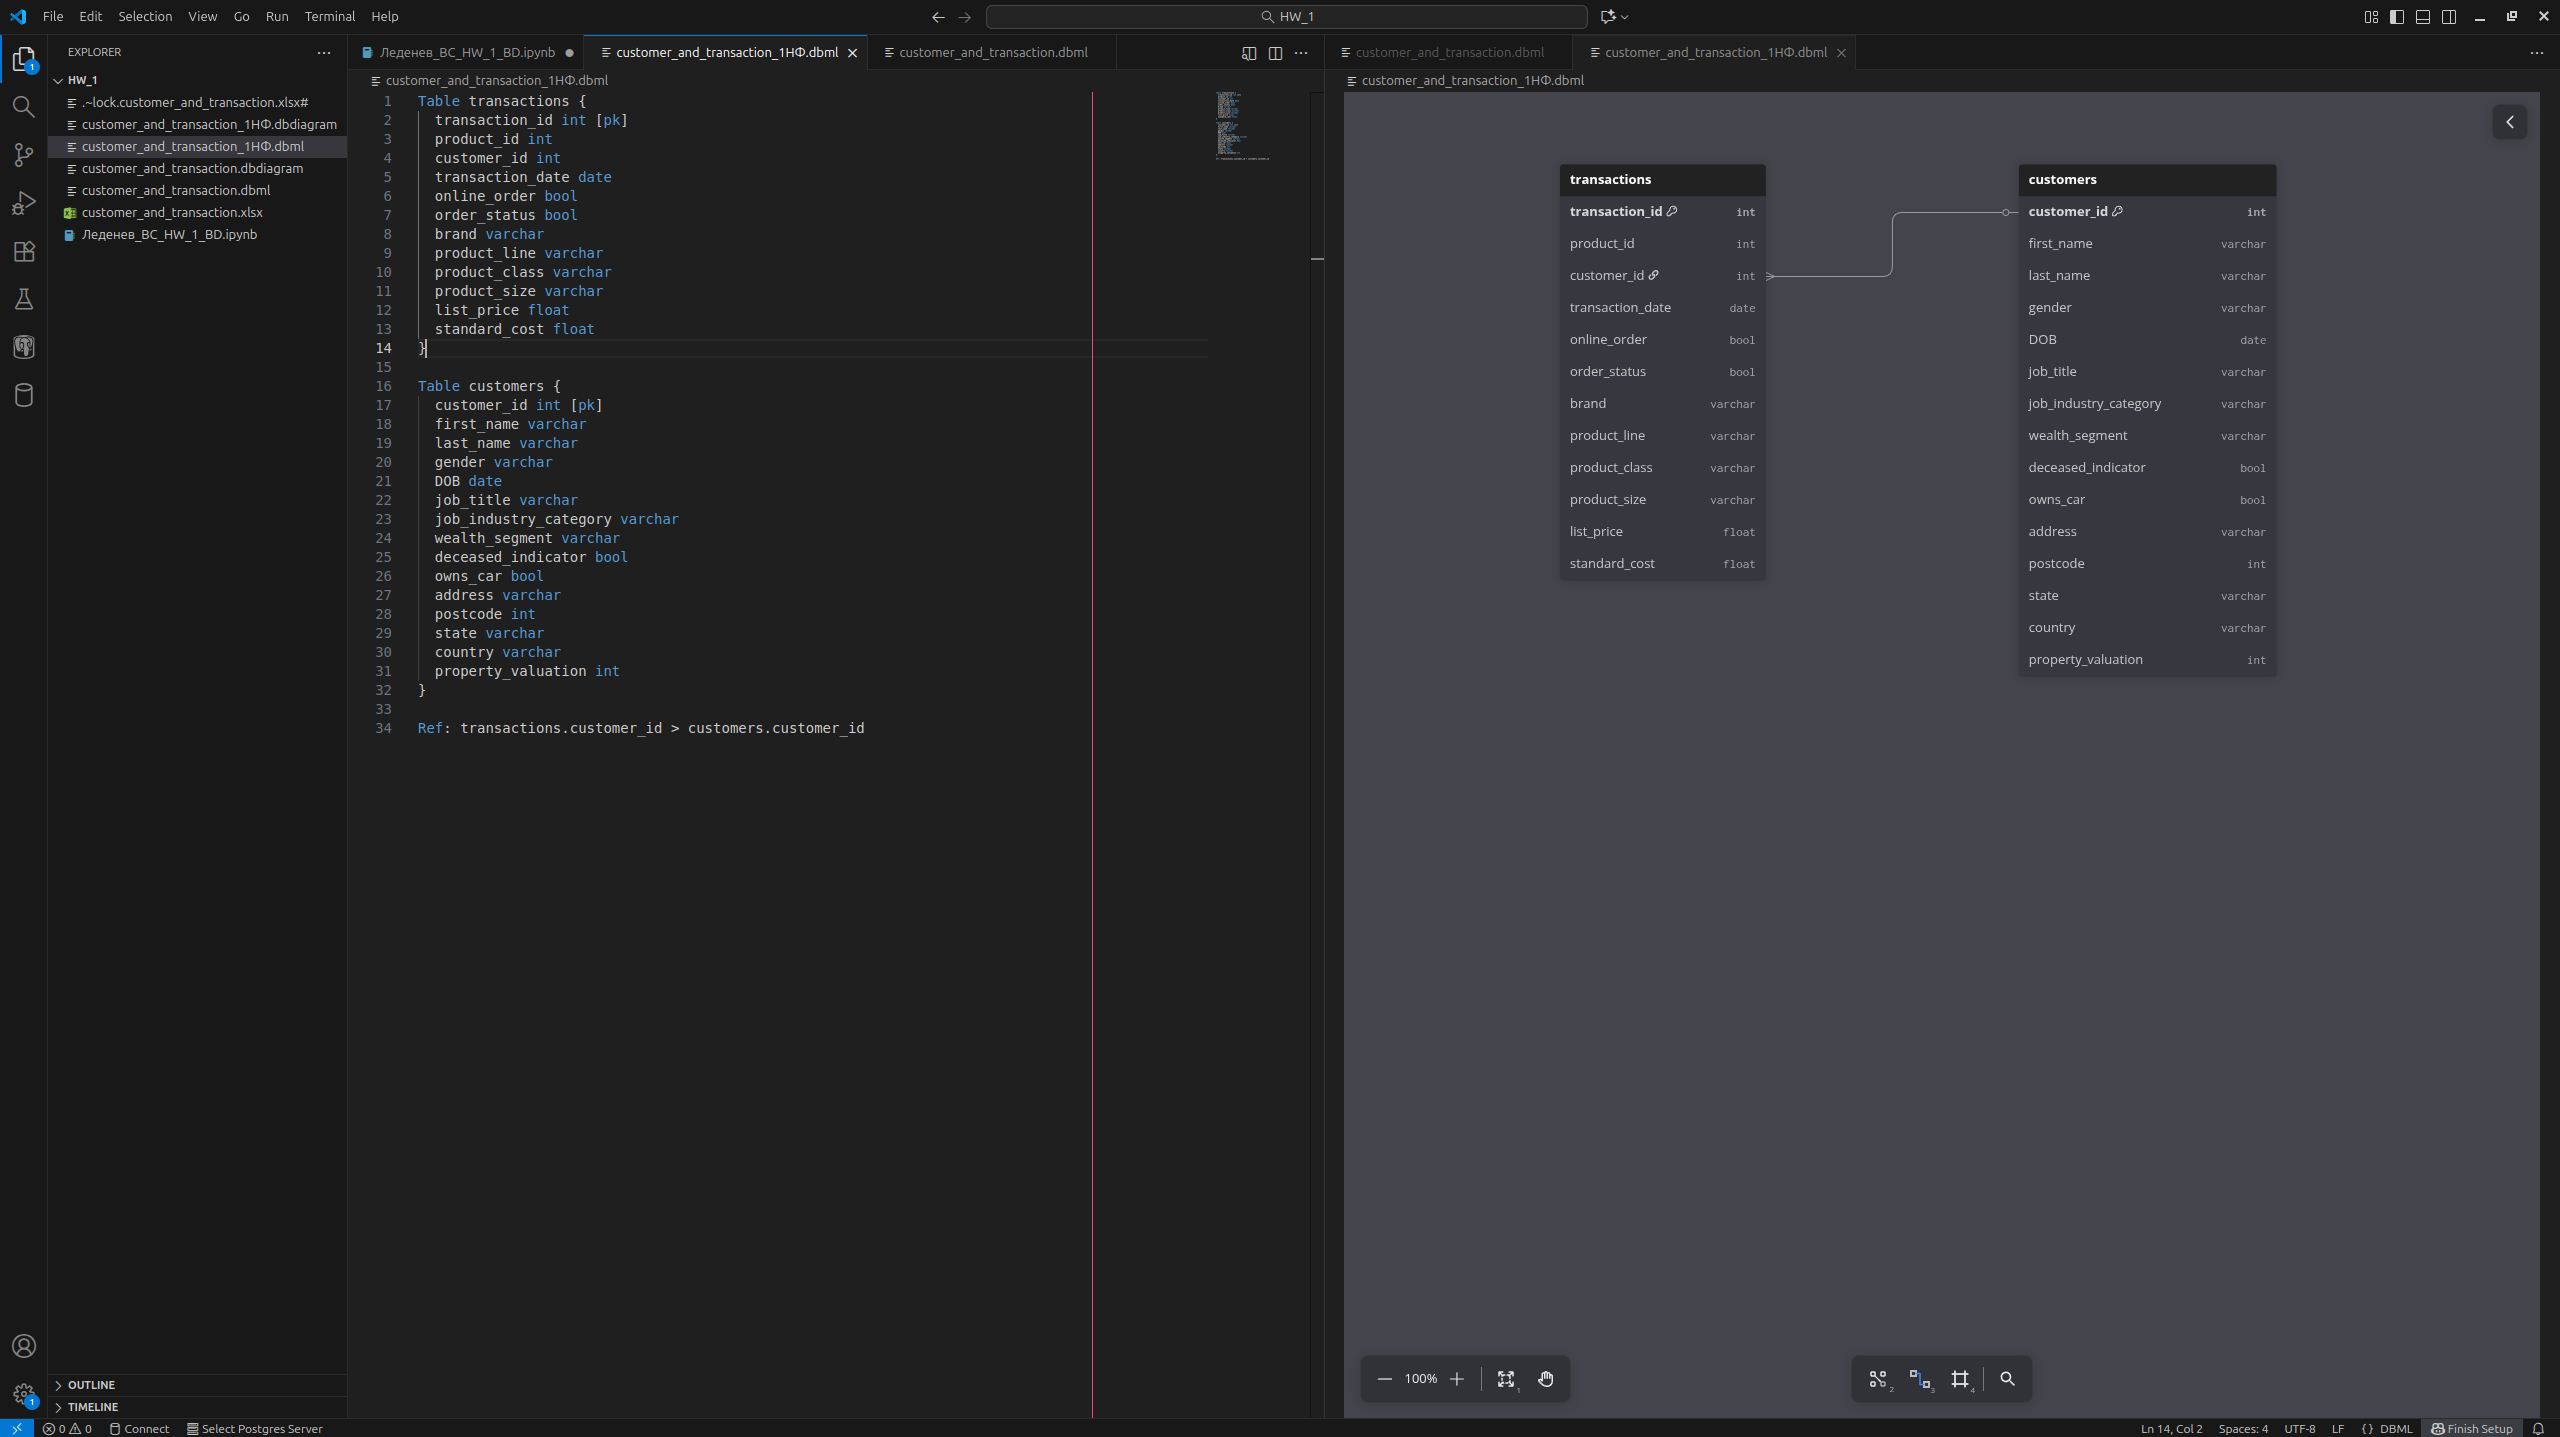

## Все атрибуты в таблице простые, данные содержат скалярные значения (нет составных значений):
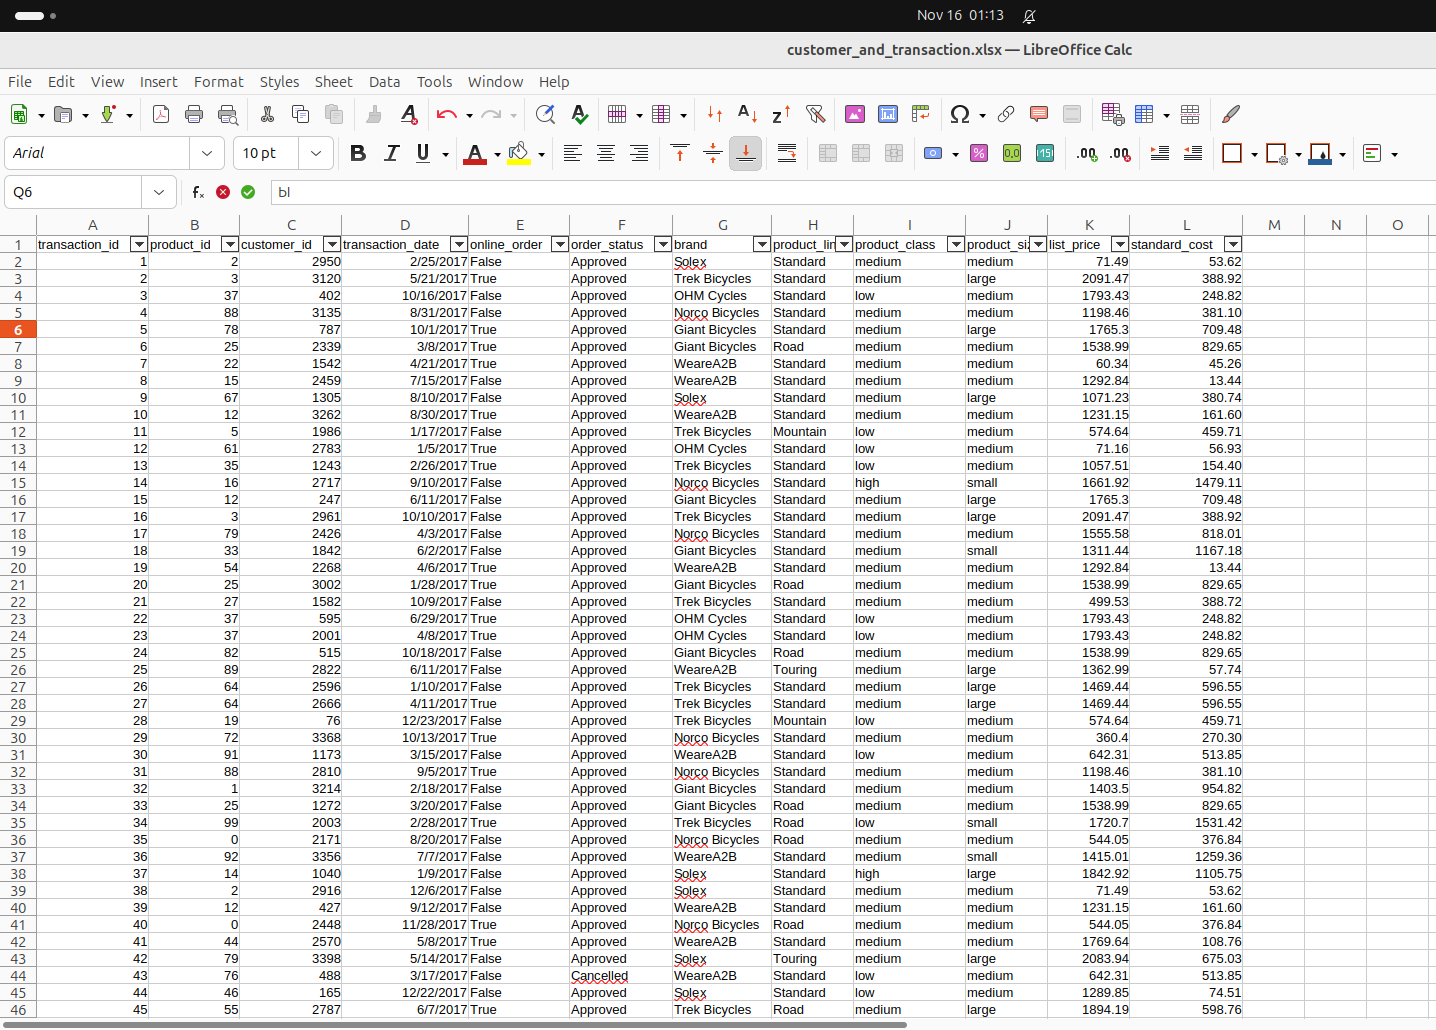


# 2. Проводим нормализацию базы данных до 3Н:
1. Выносим в отдельную таблицу **products** индекс продуктов **product_index**,
и все его характеристики:
    * **product_line** - продуктовую линейку
    * **product_class** - класс продукта
    * **product_size** - размер продукта
    * **standard_cost** - цена единицы продукта
    Добавляем к таблице новое поле **brand_id** (внешний ключ), чтобы связать 
    с таблицей с брендами, т.к. один и тот же вид товара может быть произведен
    разными фирмами.
    
    Таблицу **products** через первичный ключ **products_id** связываем с 
    таблицей **transactions** через вторичный ключ **products_id**. Связь
    один (**products**) ко многим (**transactions**), т.к. один и тот же вид
    продукта может участвовать в множестве транзакций.

2. Выносим в отдельную таблицу **brands** наименование брендов. Т.к. один и тот
же тип продукта может быть произведен разными фирамими. Поля:
    * **brand_id** - созданное поле с первичным ключем
    * **brand** - переносим поле из таблицы **transactions**

    Таблицу **brands** через первичный ключ **brand_id** связываем с 
    таблицей **products** через вторичный ключ **brand_id**. Связь
    многие (**brands**) ко многим (**products**), т.к. один и тот же вид
    продукта может производиться под разными брендами, и один и тот же бренд
    может производить разные виды продуктов. 

3. Выносим в отдельную таблицу **addresses** адреса покупателей. Т.к. один и
тот же покупатель может заказывать товар по разному адресу (на работу и домой),
на один и тот же адрес могут заказывать разные покупатели (работают вместе). Поля:
    * **address_id** - созданное поле с первичным ключем
    * **address** - переносим поле из таблицы **customers**
    * **postcode** - переносим поле из таблицы **customers**
    * **state** - переносим поле из таблицы **customers**
    * **country** - переносим поле из таблицы **customers**
    * **property_valuation** - переносим поле из таблицы **customers**

    Таблицу **addresses** через первичный ключ **address_id** связываем с 
    таблицей **customers** через вторичный ключ **address_id**. Связь
    многие (**addresses**) ко многим (**customers**), в начале п. 3 описано почему.

4. Выносим в отдельную таблицу **professions** профессии покупателей. Т.к. одину и
ту же профессию могут иметь несколько покупателей. Поля:
    * **profession_id** - созданное поле с первичным ключем
    * **job_title** - переносим поле из таблицы **customers**
    * **job_industry_category** - переносим поле из таблицы **customers**

    Таблицу **professions** через первичный ключ **profession_id** связываем с 
    таблицей **customers** через вторичный ключ **profession_id**. Связь
    один (**professions**) ко многим (**customers**), т.к. одна и та же профессия
    может быть у нескольких покупателей.

### Листинг кода, для создания диаграммы БД в 3НФ в dbml (язык разметки dbdiagram.io):
```dbml
Table transactions {
  transaction_id int [pk]
  product_id int [not null]
  customer_id int [not null]
  transaction_date date
  online_order bool
  order_status bool 
  list_price float
}

Table products {
  product_id int [pk]
  brand_id int [not null]
  product_line varchar
  product_class varchar
  product_size varchar
  standard_cost float
}

Table brands {
  brand_id int [pk]
  brand varchar
}

Table customers {
  customer_id int [pk]
  first_name varchar
  last_name varchar
  gender varchar
  date_of_birth date
  wealth_segment varchar
  deceased_indicator bool
  owns_car bool
  address_id int [not null]
  profession_id int [not null]
}

Table addresses {
  address_id int [pk]
  address varchar
  postcode int
  state varchar
  country varchar
  property_valuation int
}

Table professions {
  profession_id int [pk]
  job_title varchar
  job_industry_category varchar
}

Ref: transactions.customer_id > customers.customer_id
Ref: transactions.product_id > products.product_id
Ref: products.brand_id <> brands.brand_id
Ref: customers.address_id <> addresses.address_id
Ref: customers.profession_id > professions.profession_id
```

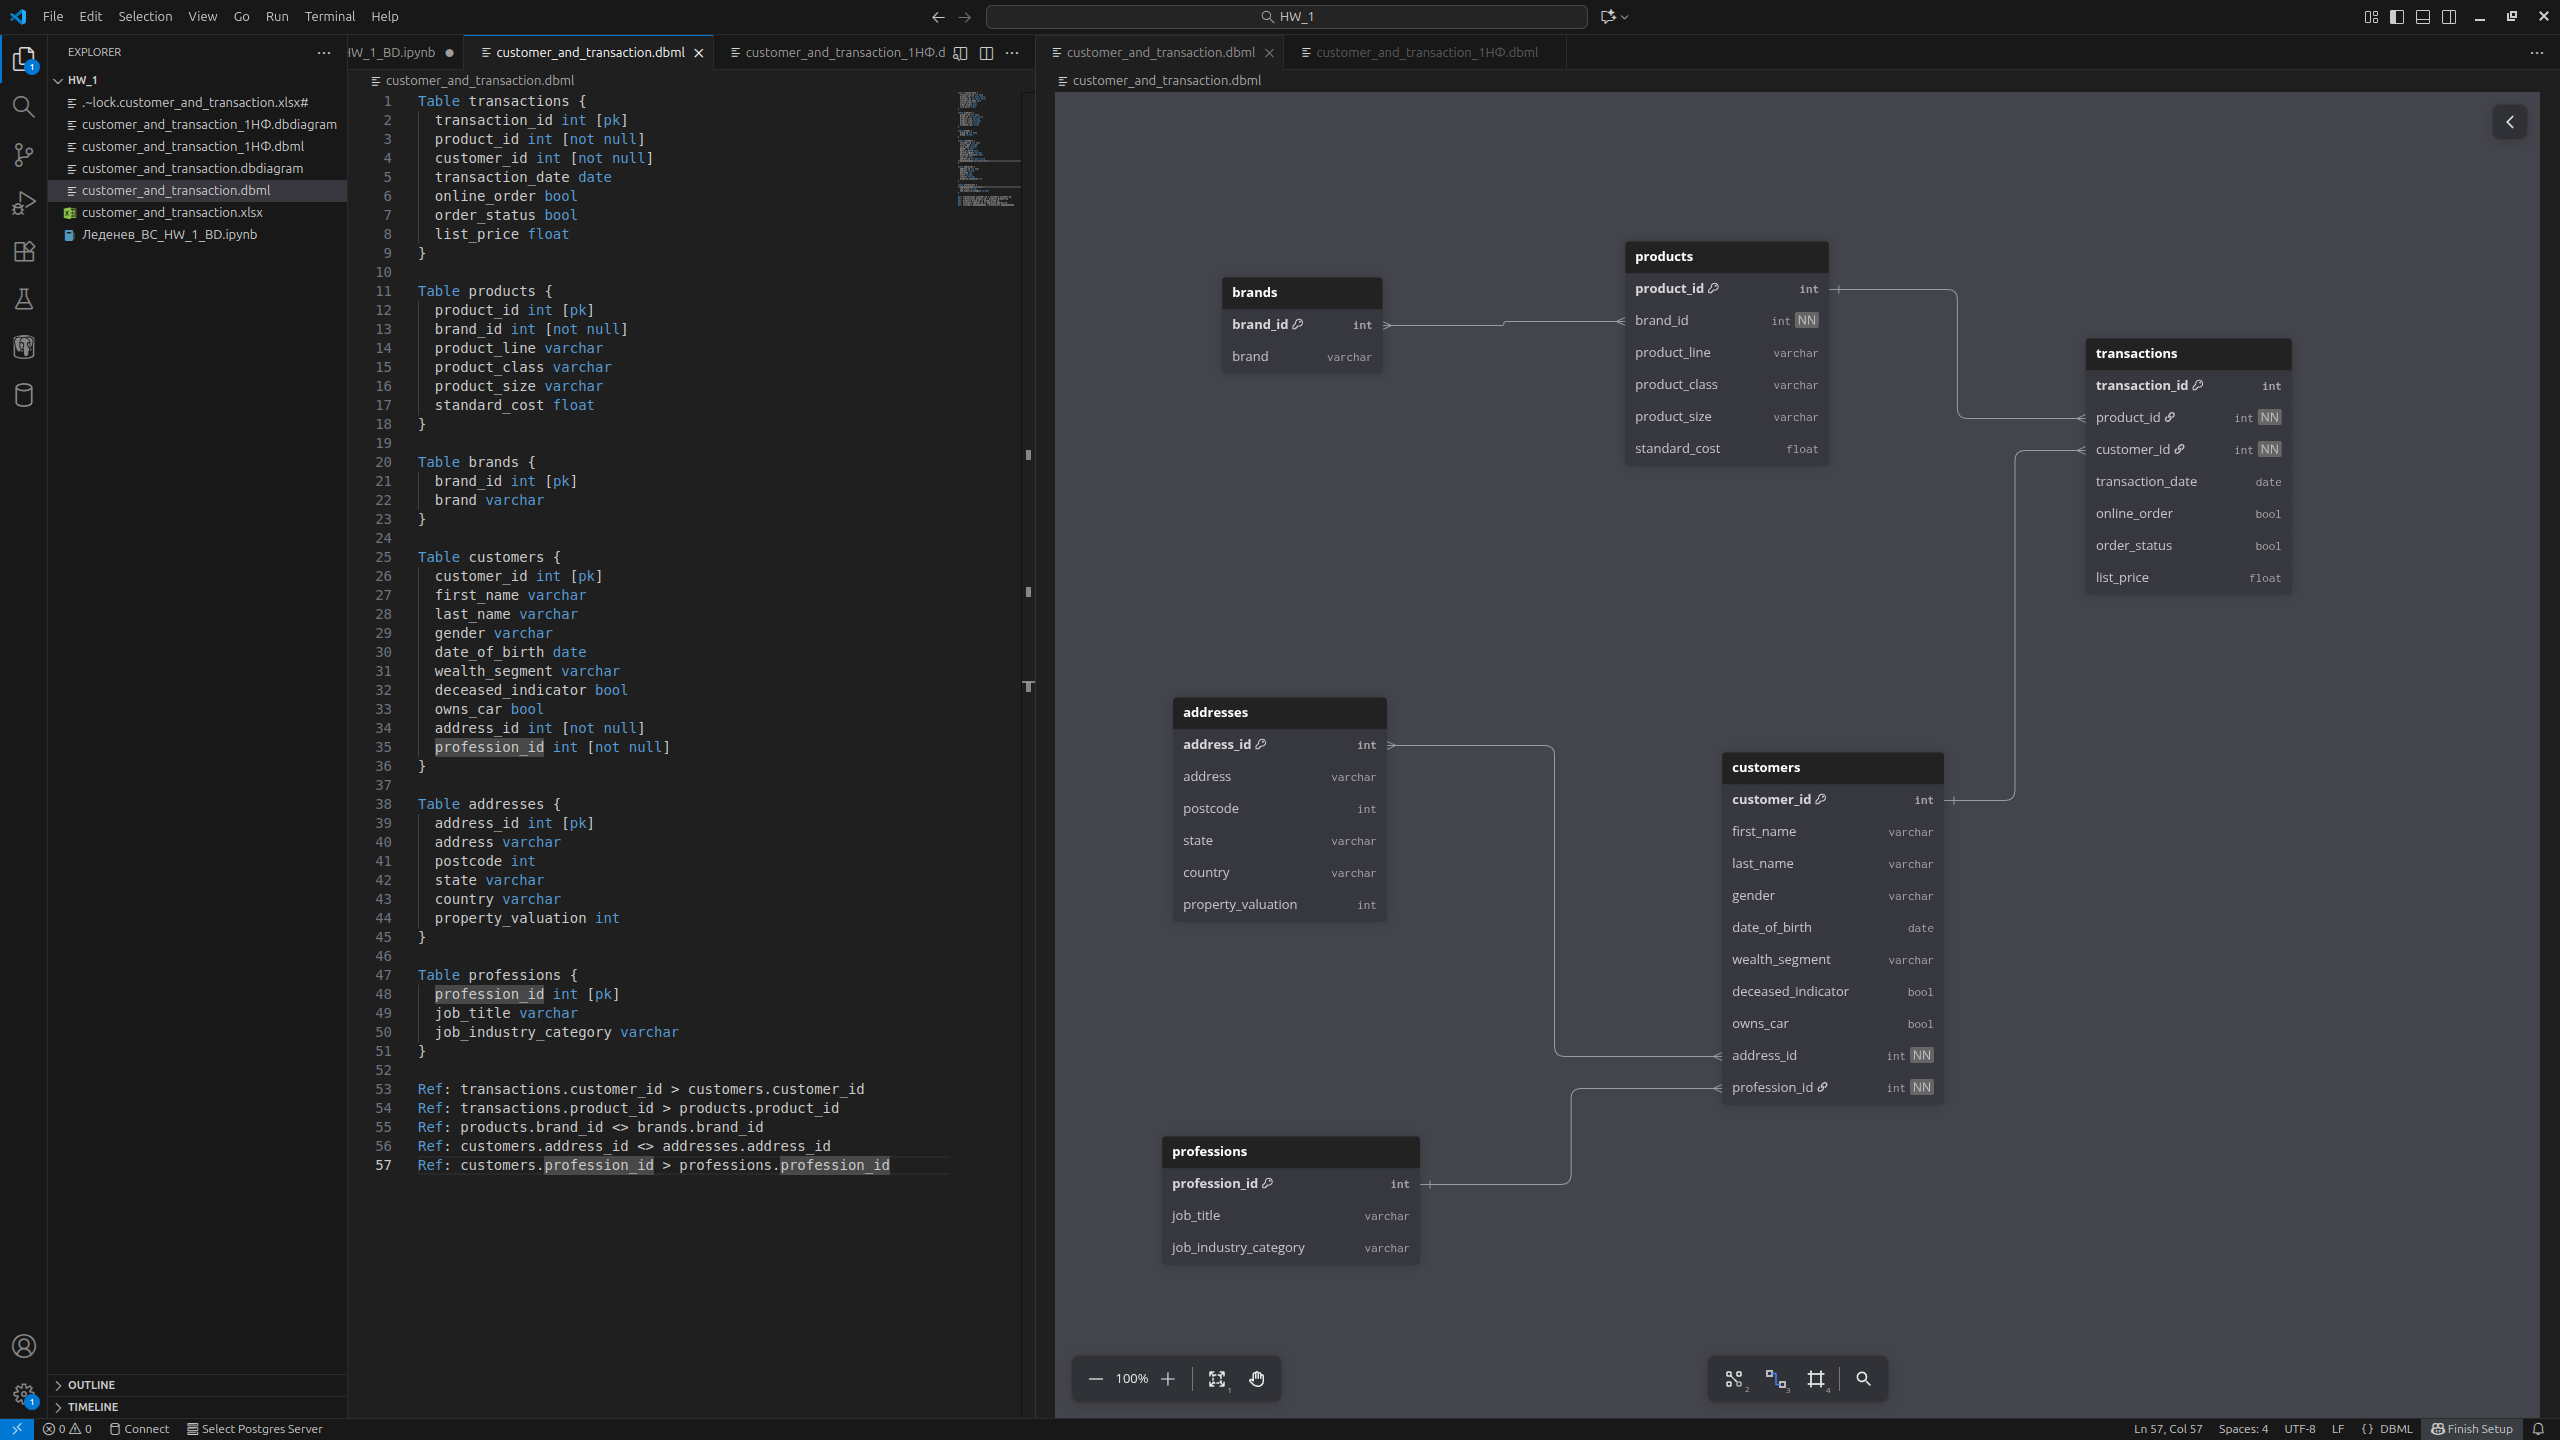

# 3. Создание таблиц в DBeaver:

## SQL скрипт для создания таблиц через DBeaver:
```sql
-- создание таблицы brands (создаем первой, т.к. участвует в связях с products)
create table brands (
    brand_id int primary key,
    brand varchar(255)
);

-- создание таблицы professions
create table professions (
    profession_id int primary key,
    job_title varchar(255),
    job_industry_category varchar(255)
);

-- создание таблицы addresses
create table addresses (
    address_id int primary key,
    address varchar(255),
    postcode int,
    state varchar(255),
    country varchar(255),
    property_valuation int
);

-- создание таблицы customers
create table customers (
    customer_id int primary key,
    first_name varchar(255),
    last_name varchar(255),
    gender varchar(255),
    date_of_birth date,
    wealth_segment varchar(255),
    deceased_indicator boolean,
    owns_car boolean,
    address_id int not null,
    profession_id int not null,
    foreign key (address_id) references addresses(address_id),
    foreign key (profession_id) references professions(profession_id)
);

-- создание таблицы products
create table products (
    product_id int primary key,
    brand_id int not null,
    product_line varchar(255),
    product_class varchar(255),
    product_size varchar(255),
    standard_cost decimal(10,2),
    foreign key (brand_id) references brands(brand_id)
);

-- создание таблицы transactions
create table transactions (
    transaction_id int primary key,
    product_id int not null,
    customer_id int not null,
    transaction_date date,
    online_order boolean,
    order_status boolean,
    list_price decimal(10,2),
    foreign key (product_id) references products(product_id),
    foreign key (customer_id) references customers(customer_id)
);
```

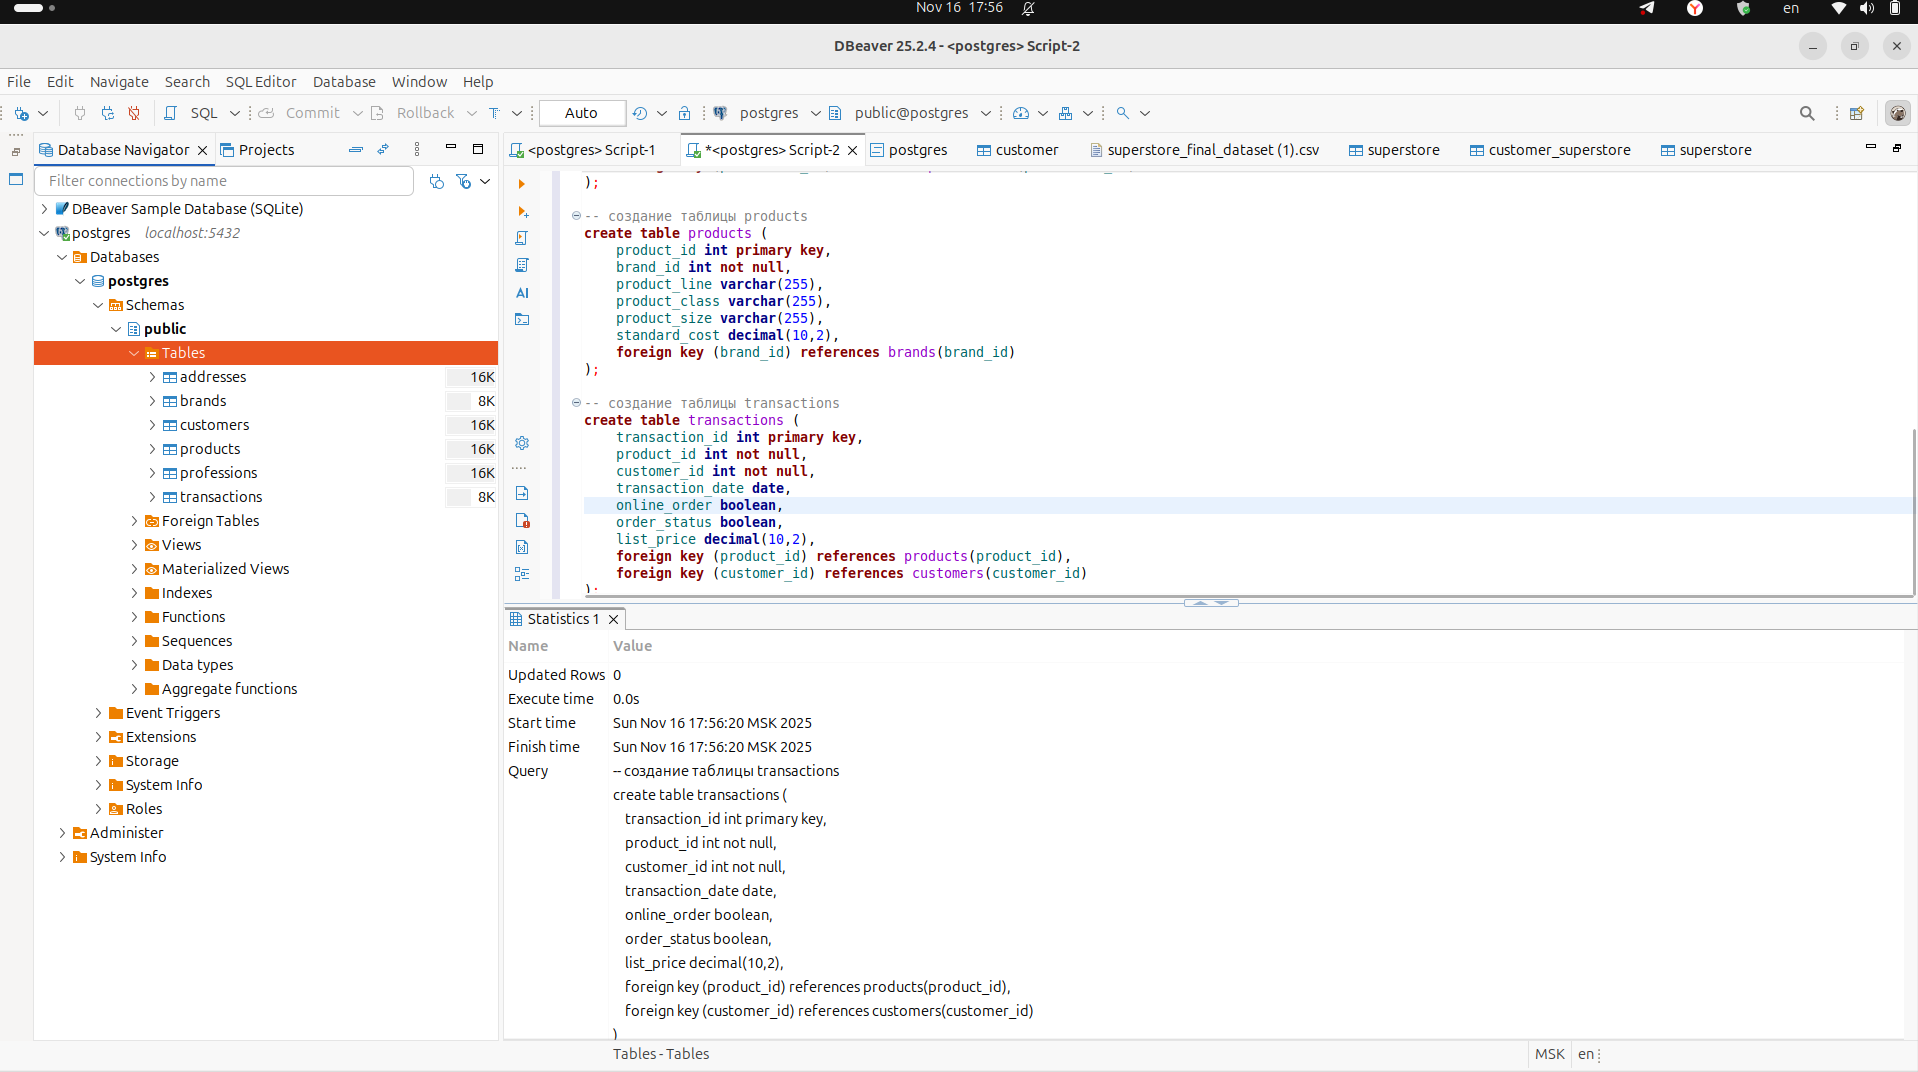

# 4. Загрузка данных в БД:


### Таблица с брендами:

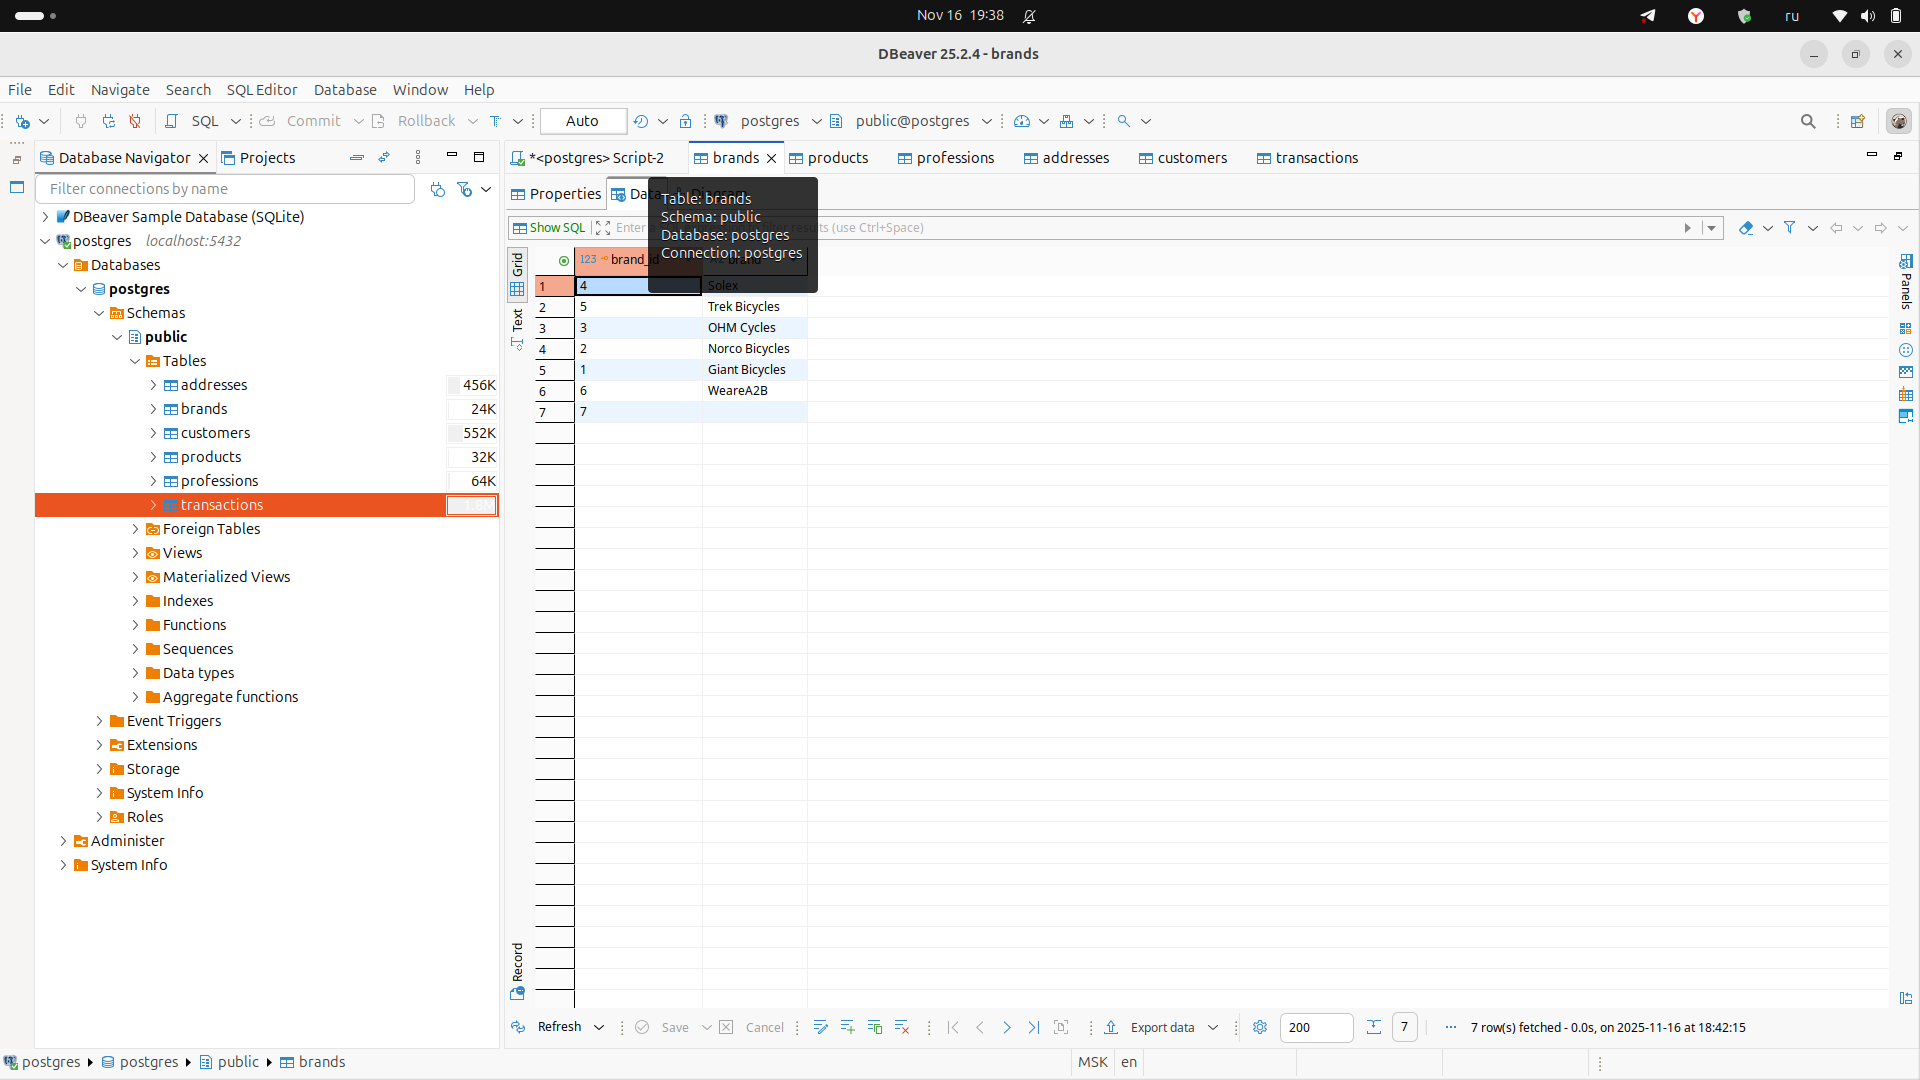

### Таблица с продуктами:

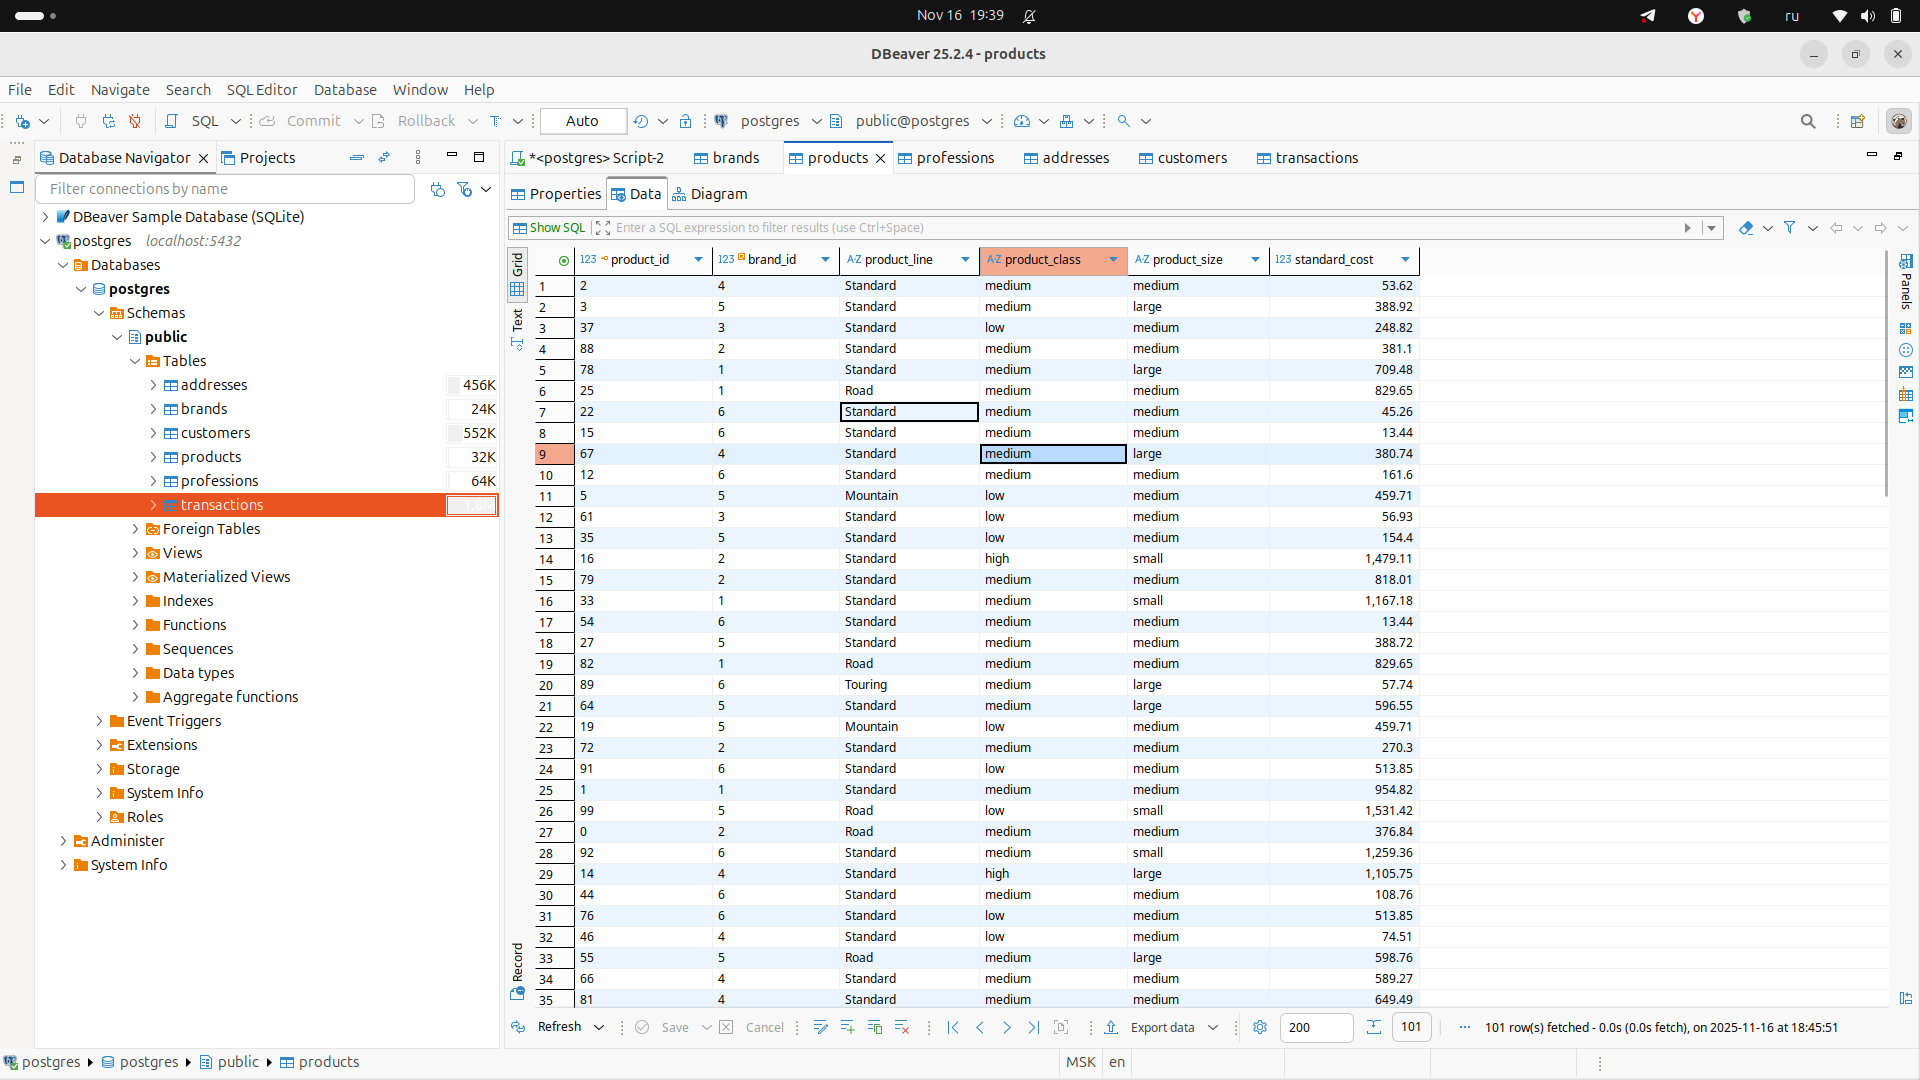

### Таблица с профессиями:

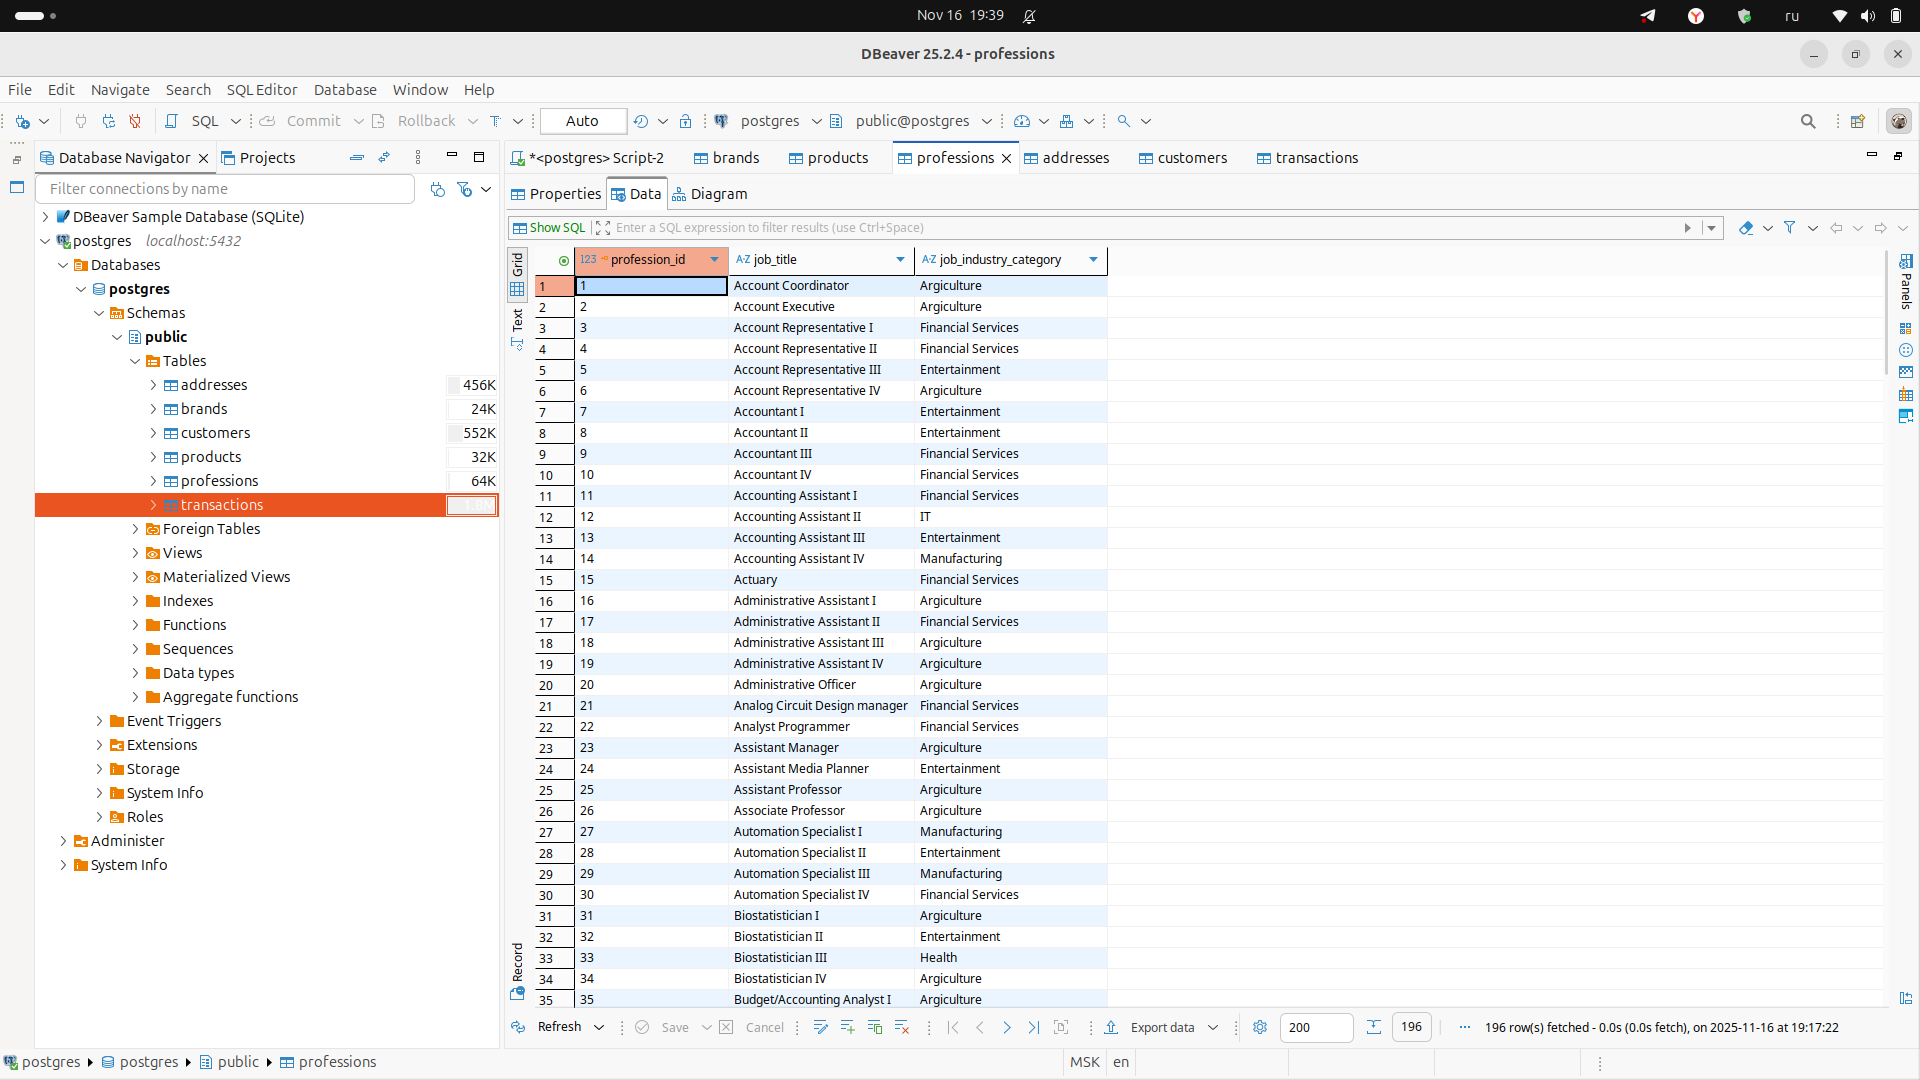

### Таблица с адресами:

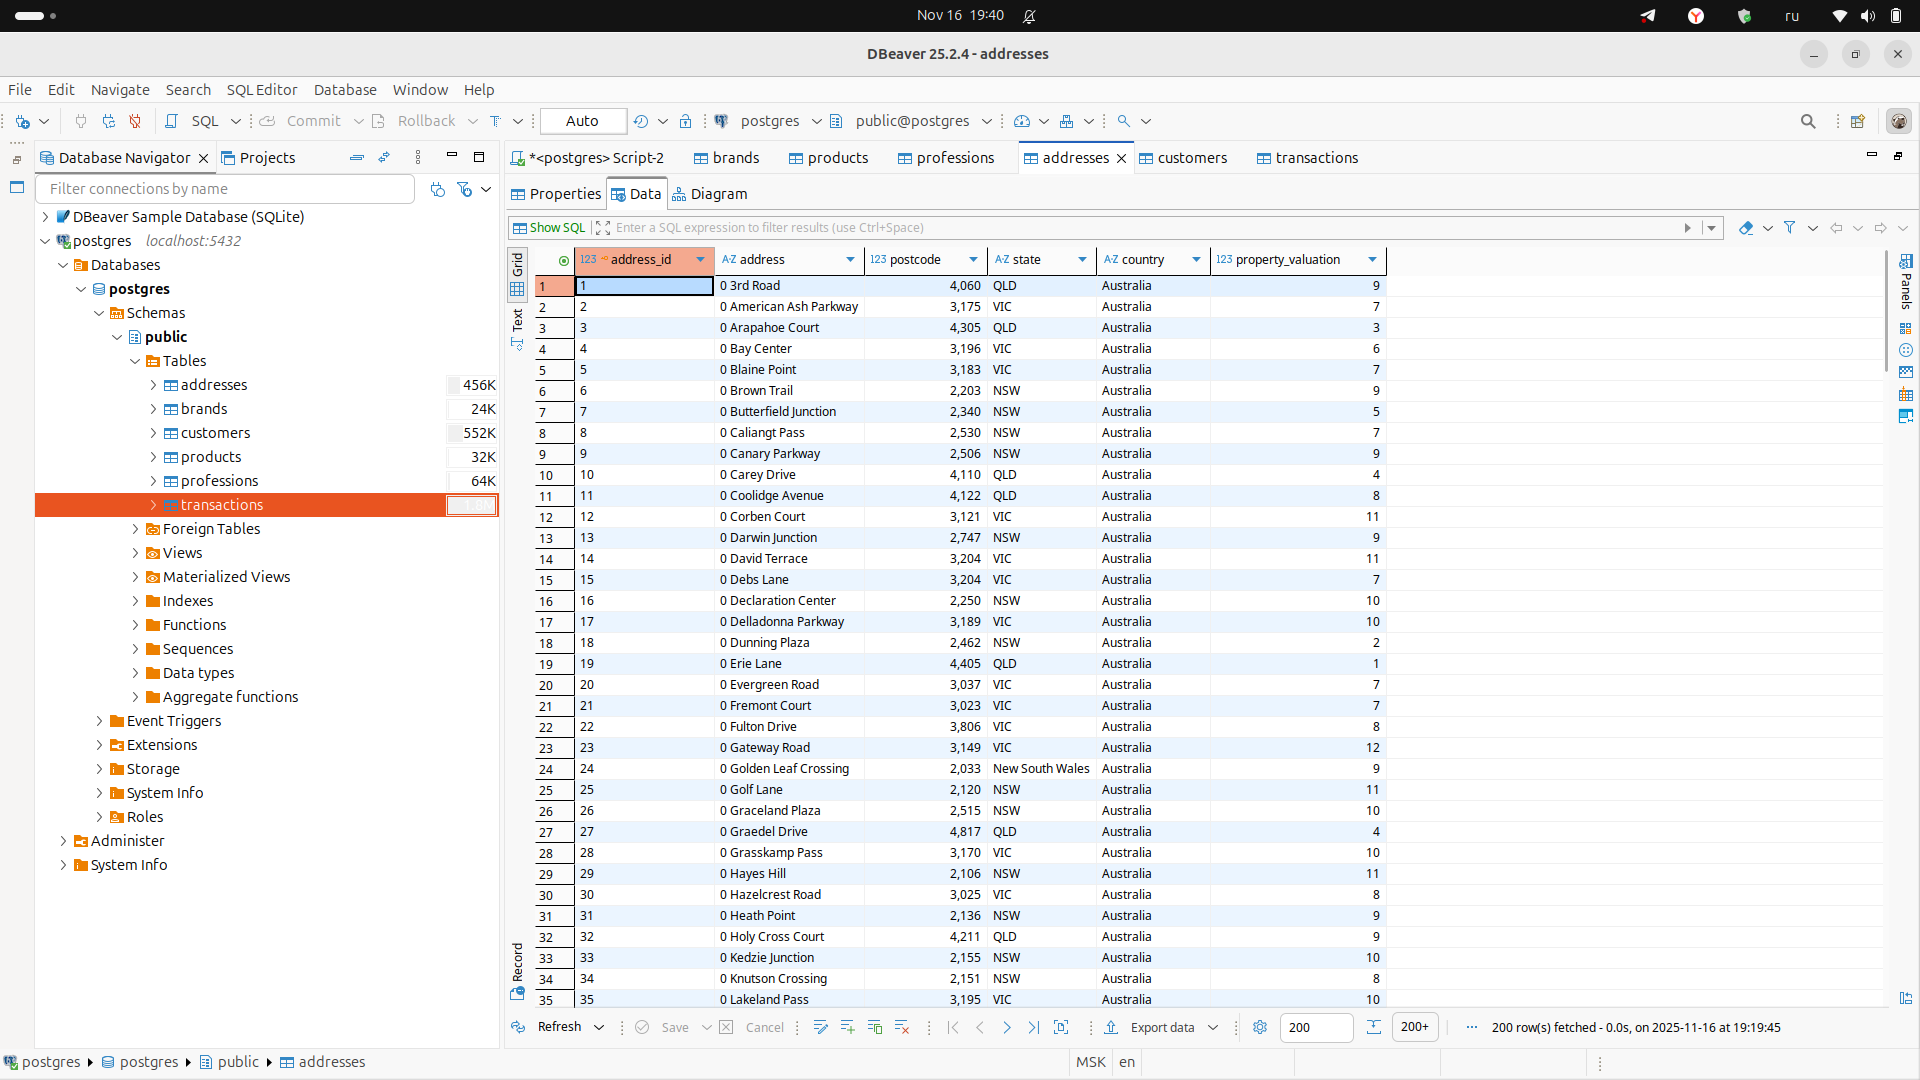

### Таблица с покупателями:

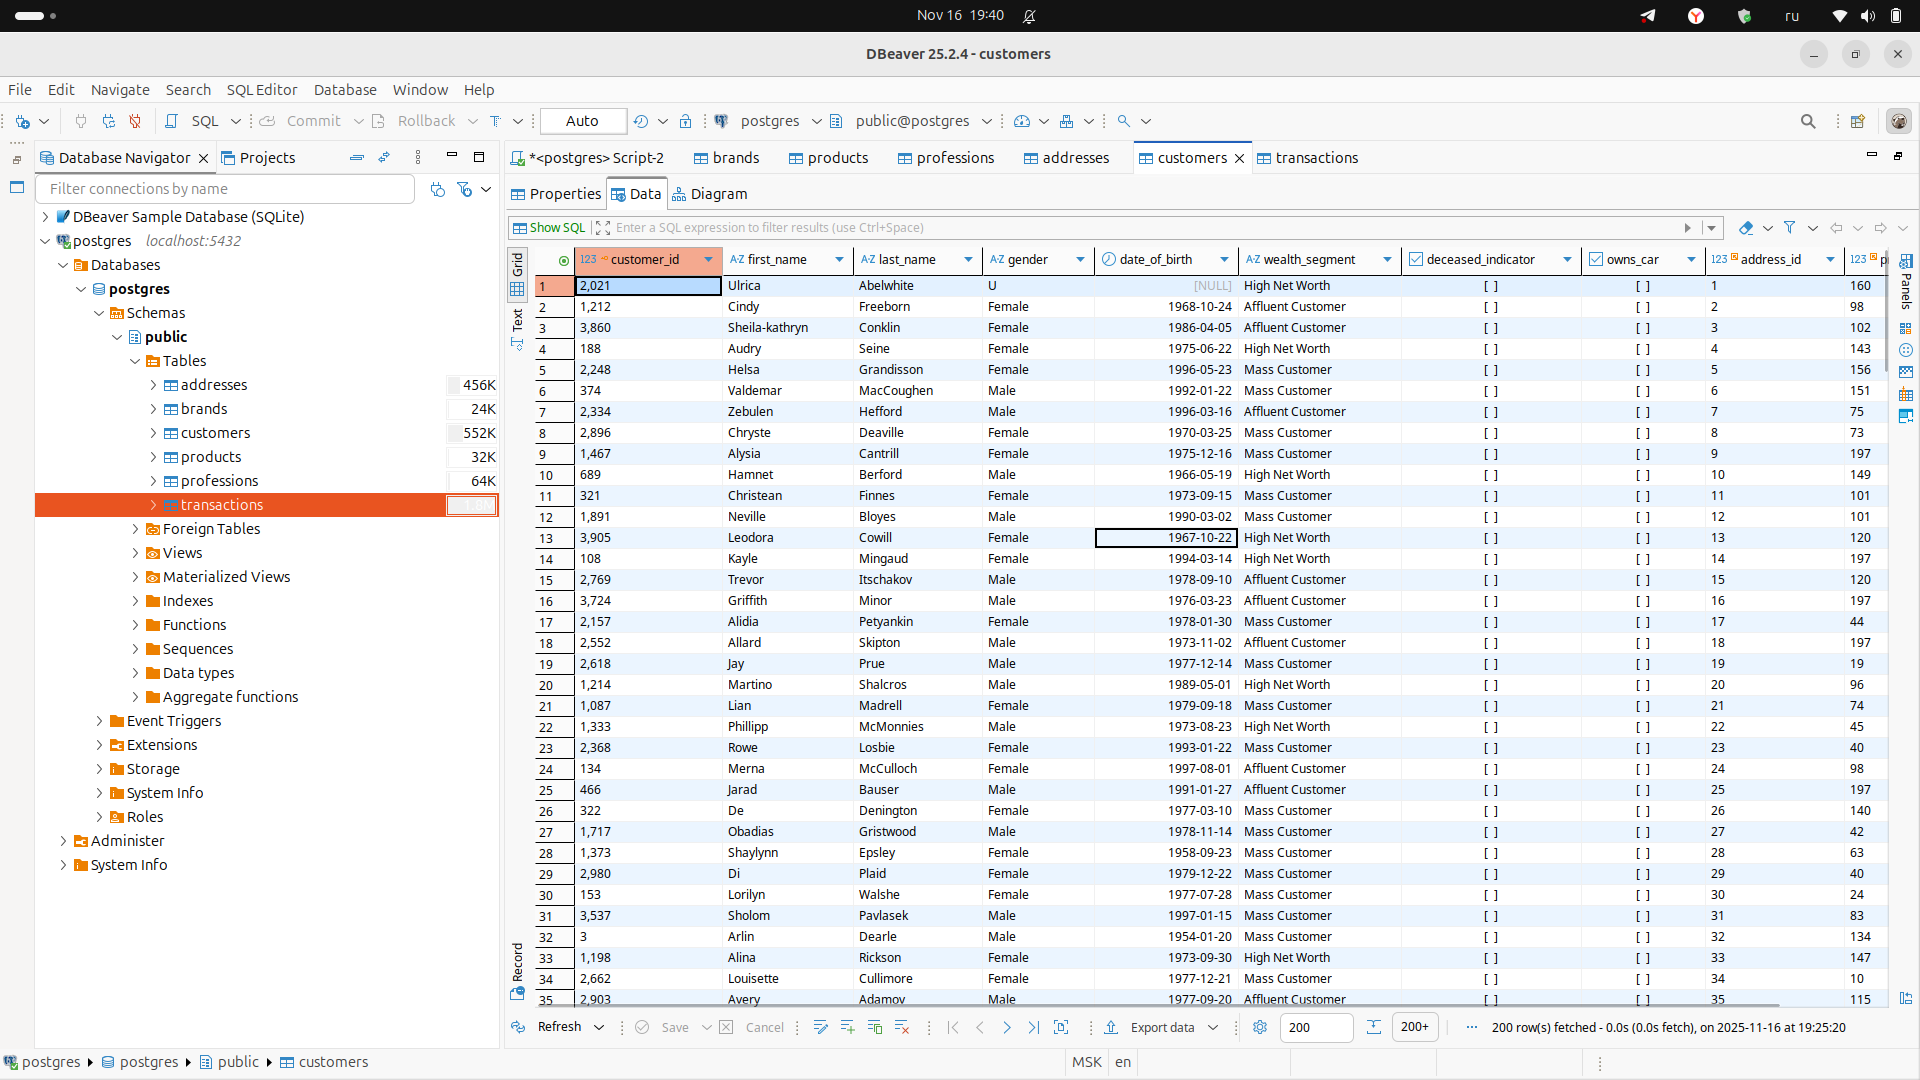

### Таблица с транзакциями:

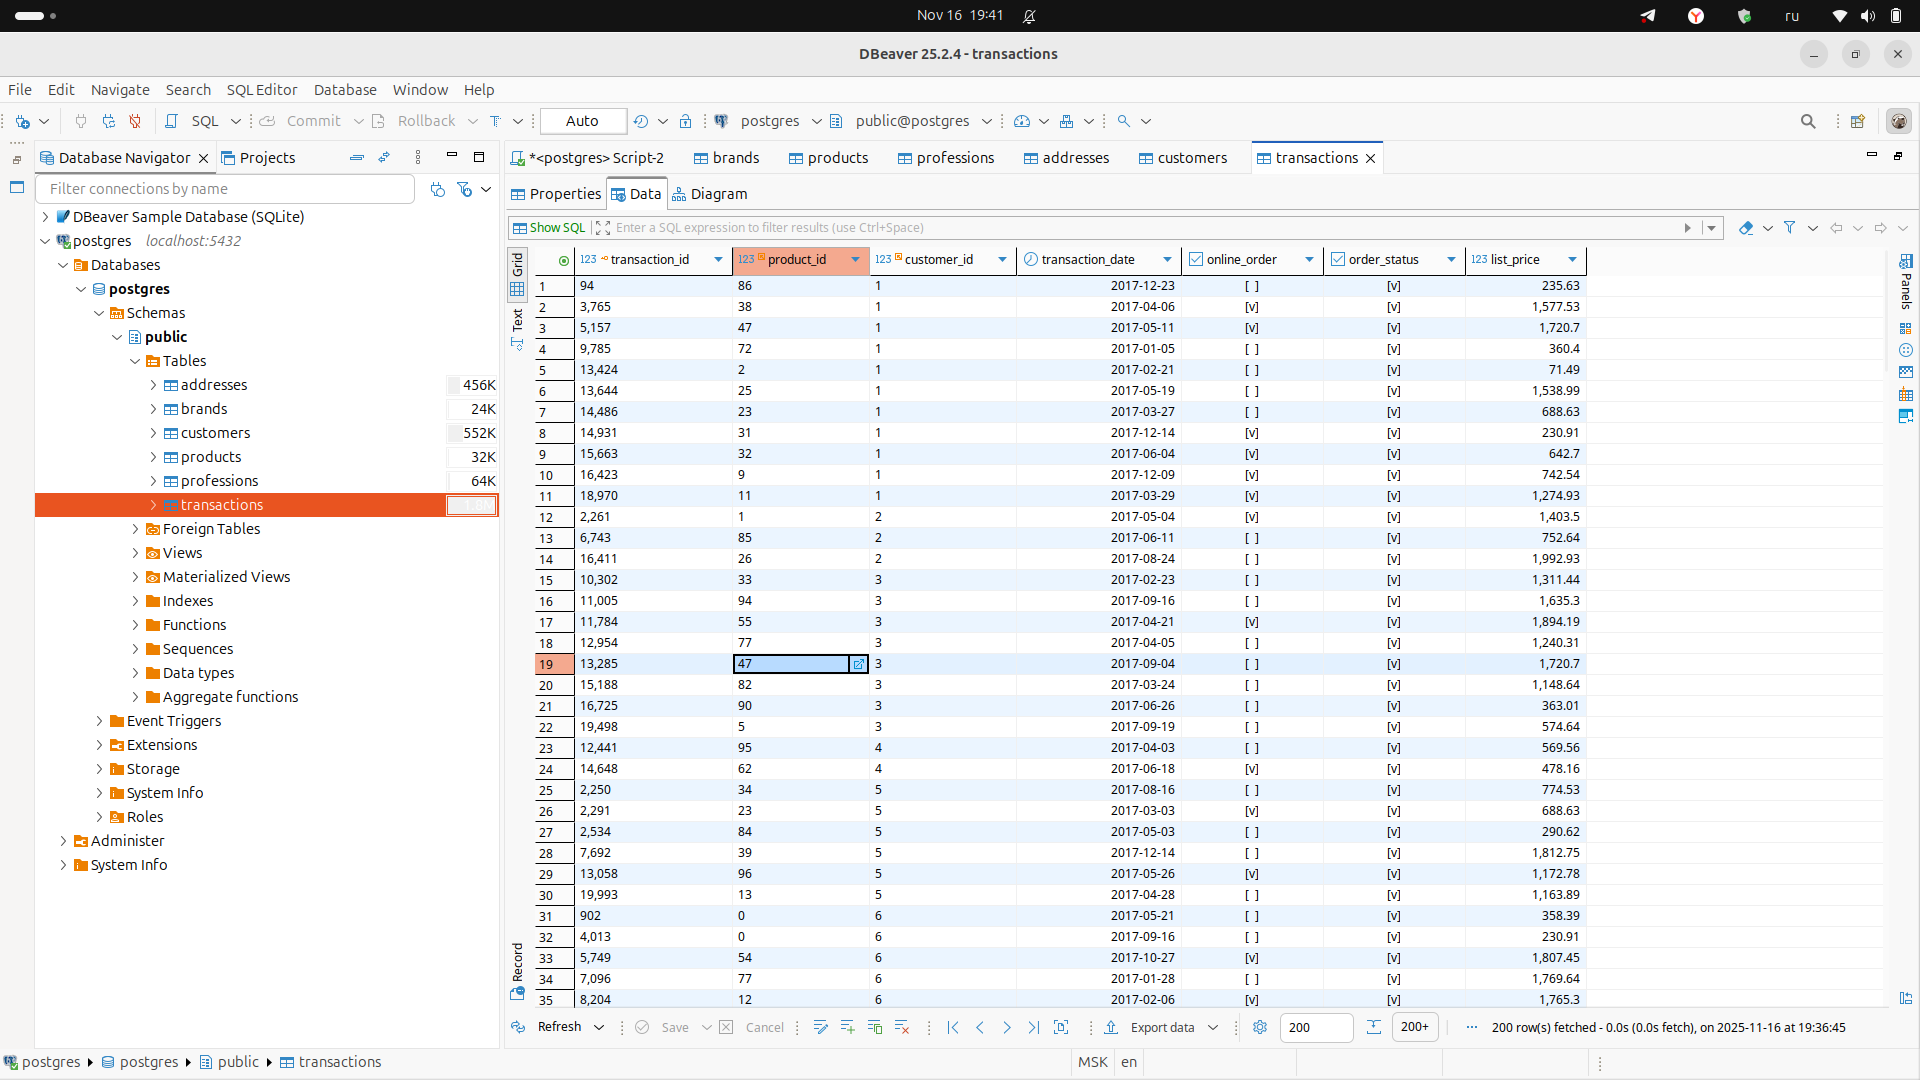

### Связи, сформированные в БД:

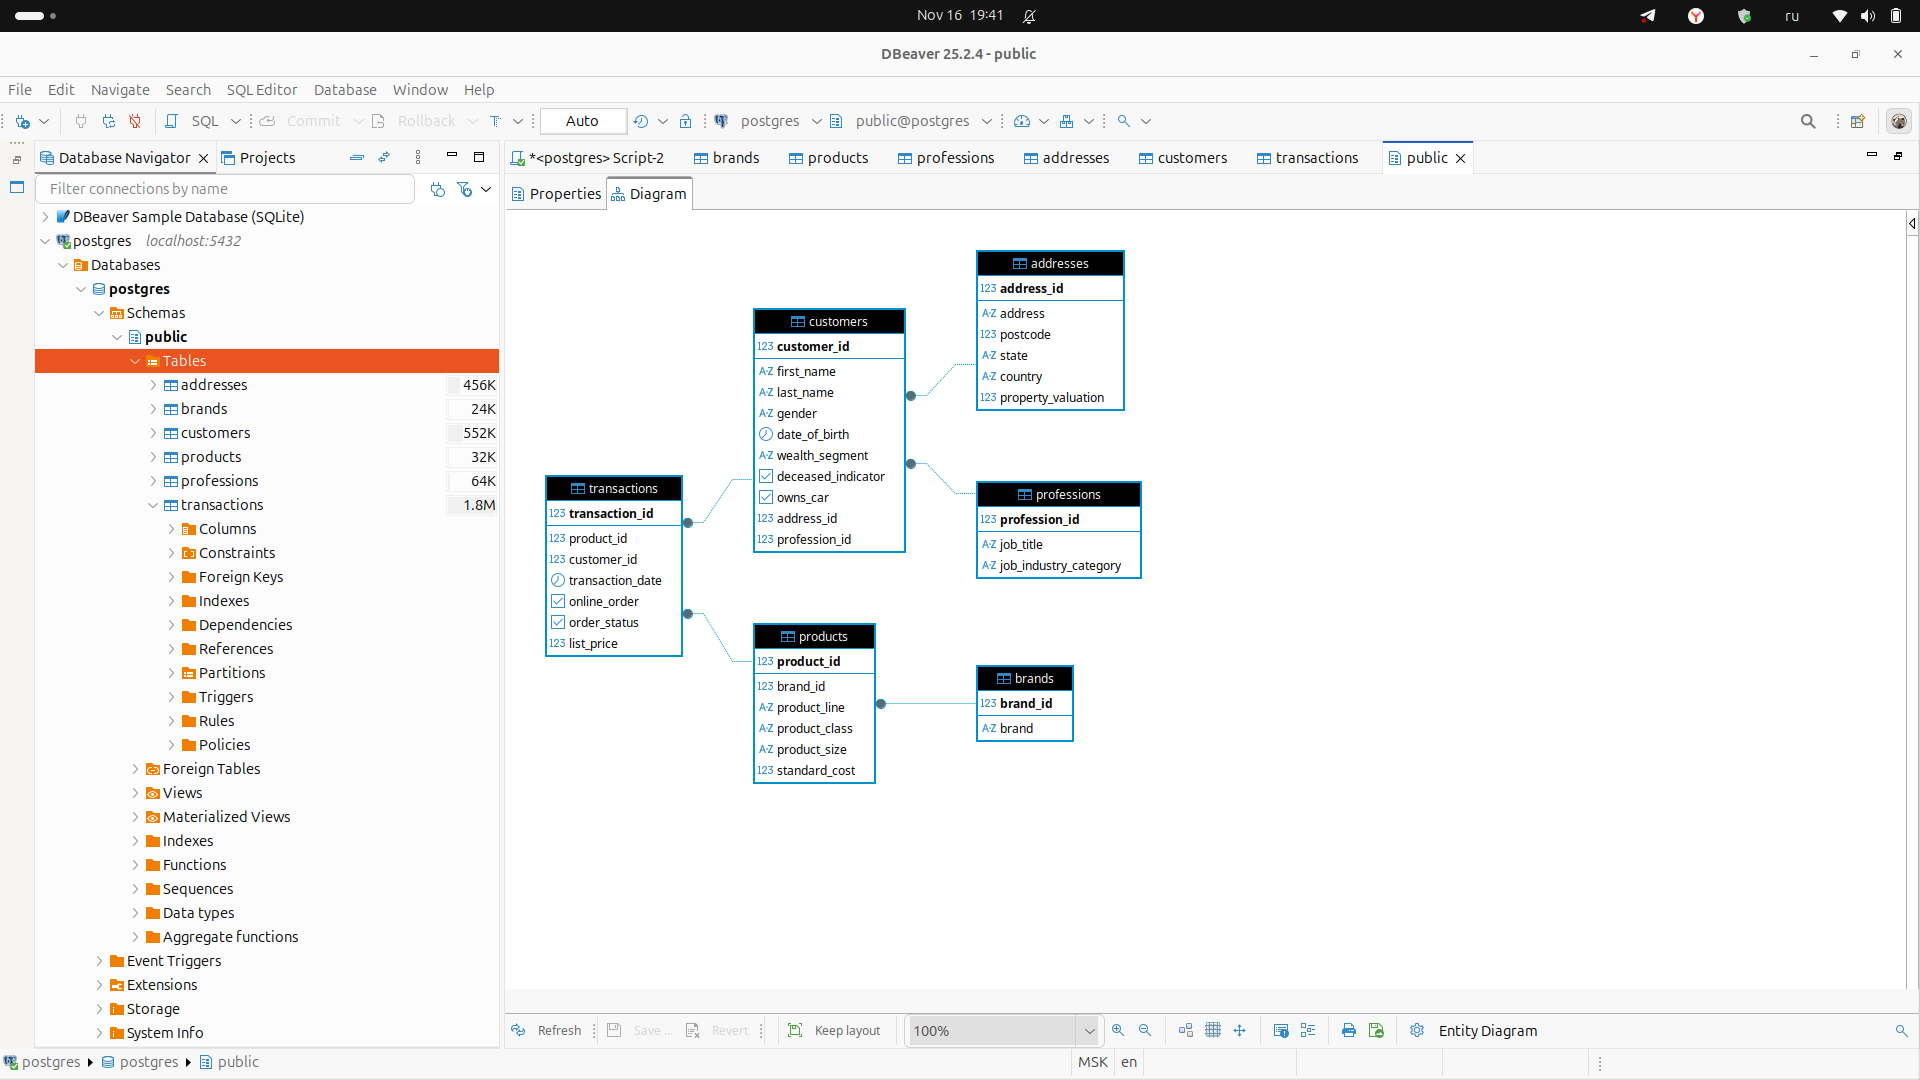